# RNN
- 순환 신경망 
    - 닫힌 경로 필요
    - 연산에 이전 연산 결과 반영
    - 시간 종속성
    - $$h_t = \tanh(h_{t-1}W_h+x_tW_x +b)$$
- 장기 기울기 소실 또는 폭발
    - tanh에 의해 역전파에서 기울기 계속 감소
    - 

In [55]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [77]:
import cupy as np 
import matplotlib.pyplot as plt

GPU = True

## truncated BPTT
- BPTT - 시간 방향 역전파법
    - 시퀀스 길이에 비례해 자원 소모 증가
    - truncated BPTT - 자원 방향
- 역전파 시, 블록 단위로 레이어의 연결을 끊음
    - 역전파 중 먼 시간 계층의 기울기 소실
    - 특정 시간 이전에는 절단해야함
- 데이터 전달 시 순서대로 전달

In [57]:
class RNN:
    def __init__(self, Wx, Wh, b):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wh), np.zeros_like(Wx), np.zeros_like(b)]
        self.cache = None

    def forward(self, x, h_prev):
        Wx, Wh, b = self.params
        t = h_prev @ Wh + x @ Wx + b
        h_next = np.tanh(t)

        self.cache = (x, h_prev, h_next)
        return h_next

    def backward(self, dh_next):
        Wx, Wh, b = self.params
        x, h_prev, h_next = self.cache

        dt = dh_next * (1 - h_next**2)
        db = np.sum(dt, axis=0)

        dWh = h_prev.T @ dt
        dWx = x.T @ dt

        dh_prev = dt @ Wh.T
        dx = dt @ Wx.T

        self.grads[0][...] = dWx
        self.grads[1][...] = dWh
        self.grads[2][...] = db

        return dx, dh_prev


## time RNN 
- 여러 RNN 묶음
    - h를 인스턴스 변수 h로 보관
    - 입력 - T개의 x $(N, T, D)$
    - 출력 - T개의 h $(N, T, H)$
- 역전파마다 중간 값 저장을 위해 순전파마다 RNN 새로 생성
    - 가중치는 동일

In [58]:
class TimeRNN:
    def __init__(self, Wx, Wh, b, stateful=False):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.layers = None

        self.h, self.dh = None, None
        self.stateful = stateful

    def set_state(self, h):
        self.h = h

    def reset_state(self, h):
        self.h = None

    def forward(self, xs):
        Wx, Wh, b = self.params
        N, T, D = xs.shape
        D, H = Wx.shape

        self.layers = []
        hs = np.empty((N, T, H), dtype="f")

        if not self.stateful or self.h is None:
            self.h = np.zeros((N, H), dtype="f")

        for t in range(T):
            layer = RNN(*self.params)
            self.h = layer.forward(xs[:, t, :], self.h)
            hs[:, t, :] = self.h
            self.layers.append(layer)

        return hs

    def backward(self, dhs):
        Wx, Wh, b = self.params
        N, T, H = dhs.shape
        D, H = Wx.shape

        dxs = np.empty((N, T, D), dtype="f")
        dh = 0
        grads = [0, 0, 0]
        for t in reversed(range(T)):
            layer = self.layers[t]
            dx, dh = layer.backward(dhs[:, t, :] + dh)
            dxs[:, t, :] = dx

            for i, grad in enumerate(layer.grads):
                grads[i] += grad

        for i, grad in enumerate(grads):
            self.grads[i][...] = grad
        self.dh = dh

        return dxs


## RNNLM
- 각 레이어가 time 대응되게 설계

In [59]:
from b2.common.time_layers import TimeEmbedding, TimeAffine, TimeSoftmaxWithLoss



class SimpleRnnlm:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        # 가중치 초기화
        embed_W = (rn(V, D) / 100).astype('f')
        rnn_Wx = (rn(D, H) / np.sqrt(D)).astype('f')
        rnn_Wh = (rn(H, H) / np.sqrt(H)).astype('f')
        rnn_b = np.zeros(H).astype('f')
        affine_W = (rn(H, V) / np.sqrt(H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        # 계층 생성
        self.layers = [
            TimeEmbedding(embed_W),
            TimeRNN(rnn_Wx, rnn_Wh, rnn_b, stateful=True),
            TimeAffine(affine_W, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.rnn_layer = self.layers[1]

        # 모든 가중치와 기울기를 리스트에 모은다.
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, xs, ts):
        for layer in self.layers:
            xs = layer.forward(xs)
        loss = self.loss_layer.forward(xs, ts)
        return loss

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        self.rnn_layer.reset_state()


## perplexity
- 모델이 정답으로 간주하는 단어의 수 - 적을 수록 성능 높음
- CEE의 exp
    - $$perplexity = e^{L_{CEE}}$$

In [60]:
from b2.common.optimizer import SGD
from datasets import ptb

# 하이퍼파라미터 설정
batch_size = 10
wordvec_size = 100
hidden_size = 100 # RNN의 은닉 상태 벡터의 원소 수
time_size = 5     # Truncated BPTT가 한 번에 펼치는 시간 크기
lr = 0.1
max_epoch = 100

# 학습 데이터 읽기(전체 중 1000개만)
corpus, word_to_id, id_to_word = ptb.load_data('train')
corpus_size = 1000
corpus = corpus[:corpus_size]
vocab_size = int(max(corpus) + 1)

xs = corpus[:-1]  # 입력
ts = corpus[1:]   # 출력(정답 레이블)
data_size = len(xs)
print('말뭉치 크기: %d, 어휘 수: %d' % (corpus_size, vocab_size))

# 학습 시 사용하는 변수
max_iters = data_size // (batch_size * time_size)
time_idx = 0
total_loss = 0
loss_count = 0
ppl_list = []

# 모델 생성
model = SimpleRnnlm(vocab_size, wordvec_size, hidden_size)
optimizer = SGD(lr)

# 미니배치의 각 샘플의 읽기 시작 위치를 계산
jump = (corpus_size - 1) // batch_size
offsets = [i * jump for i in range(batch_size)]

for epoch in range(max_epoch):
    for iter in range(max_iters):
        # 미니배치 취득
        batch_x = np.empty((batch_size, time_size), dtype='i')
        batch_t = np.empty((batch_size, time_size), dtype='i')
        for t in range(time_size):
            for i, offset in enumerate(offsets):
                batch_x[i, t] = xs[(offset + time_idx) % data_size]
                batch_t[i, t] = ts[(offset + time_idx) % data_size]
            time_idx += 1

        # 기울기를 구하여 매개변수 갱신
        loss = model.forward(batch_x, batch_t)
        model.backward()
        optimizer.update(model.params, model.grads)
        total_loss += loss
        loss_count += 1

    # 에폭마다 퍼플렉서티 평가
    ppl = np.exp(total_loss / loss_count)
    print('| 에폭 %d | 퍼플렉서티 %.2f'
          % (epoch+1, ppl))
    ppl_list.append(float(ppl))
    total_loss, loss_count = 0, 0


말뭉치 크기: 1000, 어휘 수: 418
| 에폭 1 | 퍼플렉서티 392.51
| 에폭 2 | 퍼플렉서티 263.60
| 에폭 3 | 퍼플렉서티 228.15
| 에폭 4 | 퍼플렉서티 219.41
| 에폭 5 | 퍼플렉서티 208.18
| 에폭 6 | 퍼플렉서티 202.95
| 에폭 7 | 퍼플렉서티 199.39
| 에폭 8 | 퍼플렉서티 197.16
| 에폭 9 | 퍼플렉서티 192.45
| 에폭 10 | 퍼플렉서티 193.90
| 에폭 11 | 퍼플렉서티 189.38
| 에폭 12 | 퍼플렉서티 192.41
| 에폭 13 | 퍼플렉서티 190.02
| 에폭 14 | 퍼플렉서티 190.86
| 에폭 15 | 퍼플렉서티 189.60
| 에폭 16 | 퍼플렉서티 186.53
| 에폭 17 | 퍼플렉서티 184.43
| 에폭 18 | 퍼플렉서티 181.27
| 에폭 19 | 퍼플렉서티 182.59
| 에폭 20 | 퍼플렉서티 182.61
| 에폭 21 | 퍼플렉서티 181.55
| 에폭 22 | 퍼플렉서티 178.03
| 에폭 23 | 퍼플렉서티 173.96
| 에폭 24 | 퍼플렉서티 177.07
| 에폭 25 | 퍼플렉서티 174.07
| 에폭 26 | 퍼플렉서티 173.98
| 에폭 27 | 퍼플렉서티 169.84
| 에폭 28 | 퍼플렉서티 168.01
| 에폭 29 | 퍼플렉서티 165.96
| 에폭 30 | 퍼플렉서티 158.19
| 에폭 31 | 퍼플렉서티 160.12
| 에폭 32 | 퍼플렉서티 154.94
| 에폭 33 | 퍼플렉서티 154.33
| 에폭 34 | 퍼플렉서티 147.95
| 에폭 35 | 퍼플렉서티 147.93
| 에폭 36 | 퍼플렉서티 142.45
| 에폭 37 | 퍼플렉서티 139.47
| 에폭 38 | 퍼플렉서티 134.00
| 에폭 39 | 퍼플렉서티 127.45
| 에폭 40 | 퍼플렉서티 122.01
| 에폭 41 | 퍼플렉서티 122.70
| 에폭 42 | 퍼플렉서티 116.02
| 에폭 43 | 퍼플렉서티 112

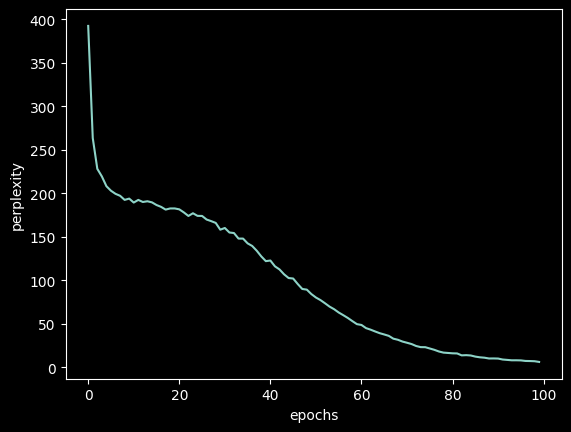

In [61]:
import numpy
# 그래프 그리기
ppl_list_np = [float(ppl.get()) if hasattr(ppl, "get") else float(ppl) for ppl in ppl_list]
x = numpy.arange(len(ppl_list))
plt.plot(x, ppl_list, label='train')
plt.xlabel('epochs')
plt.ylabel('perplexity')
plt.show()


## 기울기 폭주 및 소실
- tanh에 의한 기울기 감소
- 행렬곱에 의해 계층별로 동일한 가중치가 계속 누적
- 이거 논문 보고 정확한 이유 알아놔야함 - 책 설명 너무 부족

In [ ]:
N = 2
H = 3
T = 20

dh = np.ones((N, H))

np.random.seed(3) 

Wh = np.random.randn(H, H)
#Wh = np.random.randn(H, H) * 0.5

norm_list = []
for t in range(T):
    dh = np.dot(dh, Wh.T)
    norm = np.sqrt(np.sum(dh**2)) / N
    norm_list.append(norm)

print(norm_list)

plt.plot(np.arange(len(norm_list)), norm_list)
plt.xticks([0, 4, 9, 14, 19], [1, 5, 10, 15, 20])
plt.xlabel('시간 크기(time step)')
plt.ylabel('노름(norm)')
plt.show()


### 기울기 클리핑
- 기울기 크기가 임계값을 넘어가면, 방향은 유지한 채 크기만 임계값까지 감소
- 정확한 의미는 확인해봐야함
- 기울기 클리핑이 실제 효과가 있는지, 어떤거에 있는지 확인해야함 - 기울기 폭주로 망가지는 학습 데이터 몇개 찾아서 안정화되는거 보일 수 있으면 좋을 듯

In [78]:
dW1 = np.random.rand(3, 3) * 10
dW2 = np.random.rand(3, 3) * 10
grads = [dW1, dW2]
max_norm = 5.0


def clip_grads(grads, max_norm):
    total_norm = 0
    for grad in grads:
        total_norm += np.sum(grad ** 2)
    total_norm = np.sqrt(total_norm)

    rate = max_norm / (total_norm + 1e-6)
    if rate < 1:
        for grad in grads:
            grad *= rate


print('before:', dW1.flatten())
clip_grads(grads, max_norm)
print('after:', dW1.flatten())


before: [8.37130218 0.44352069 9.29250851 6.62383817 1.81107509 8.0903571
 6.83436528 4.24521545 7.64960269]
after: [1.85613998 0.09834031 2.06039589 1.46868081 0.40156344 1.793847
 1.51536026 0.94127699 1.69612004]
